In [6]:
import pandas as pd
import networkx as nx
import json

In [12]:
with open("data/MC3_graph.json") as f:
    data = json.load(f)

nodes = data["nodes"]
edges = data["edges"]


In [15]:
print(f"Length Nodes: {len(nodes)}, Length Edges: {len(edges)}")
print(nodes[0])
print(edges[0])

Length Nodes: 1159, Length Edges: 3226
{'type': 'Entity', 'label': 'Sam', 'name': 'Sam', 'sub_type': 'Person', 'id': 'Sam'}
{'id': '2', 'is_inferred': True, 'source': 'Sam', 'target': 'Relationship_Suspicious_217'}


In [17]:
G = nx.Graph()

for node in nodes:
    node_id = node["id"]
    attrs = {k: v for k, v in node.items() if k != "id"}
    G.add_node(node_id, **attrs)

for edge in edges:
    source = edge["source"]
    target = edge["target"]
    attrs = {k: v for k, v in edge.items() if k not in ["source", "target"]}
    G.add_edge(source, target, **attrs)

print("Nodes:", G.nodes(data=True))
print("Edges:", G.edges(data=True))

Nodes: [('Sam', {'type': 'Entity', 'label': 'Sam', 'name': 'Sam', 'sub_type': 'Person'}), ('Kelly', {'type': 'Entity', 'label': 'Kelly', 'name': 'Kelly', 'sub_type': 'Person'}), ('Nadia Conti', {'type': 'Entity', 'label': 'Nadia Conti', 'name': 'Nadia Conti', 'sub_type': 'Person'}), ('Elise', {'type': 'Entity', 'label': 'Elise', 'name': 'Elise', 'sub_type': 'Person'}), ('Liam Thorne', {'type': 'Entity', 'label': 'Liam Thorne', 'name': 'Liam Thorne', 'sub_type': 'Person'}), ('Samantha Blake', {'type': 'Entity', 'label': 'Samantha Blake', 'name': 'Samantha Blake', 'sub_type': 'Person'}), ('Davis', {'type': 'Entity', 'label': 'Davis', 'name': 'Davis', 'sub_type': 'Person'}), ('Rodriguez', {'type': 'Entity', 'label': 'Rodriguez', 'name': 'Rodriguez', 'sub_type': 'Person'}), ('Sailor Shift', {'type': 'Entity', 'label': 'Sailor Shift', 'name': 'Sailor Shift', 'sub_type': 'Person'}), ('Clepper Jensen', {'type': 'Entity', 'label': 'Clepper Jensen', 'name': 'Clepper Jensen', 'sub_type': 'Person

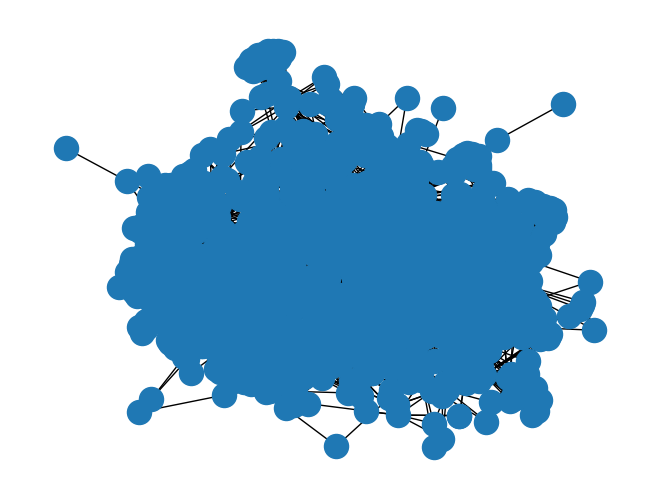

In [22]:
import matplotlib.pyplot as plt

nx.draw(G)
plt.show()


In [23]:
nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index").reset_index()
nodes_df.rename(columns={"index": "id"}, inplace=True)


In [34]:
G = nx.readwrite.json_graph.node_link_graph(data, directed=True, edges="edges")

In [49]:
pos = nx.spring_layout(G)

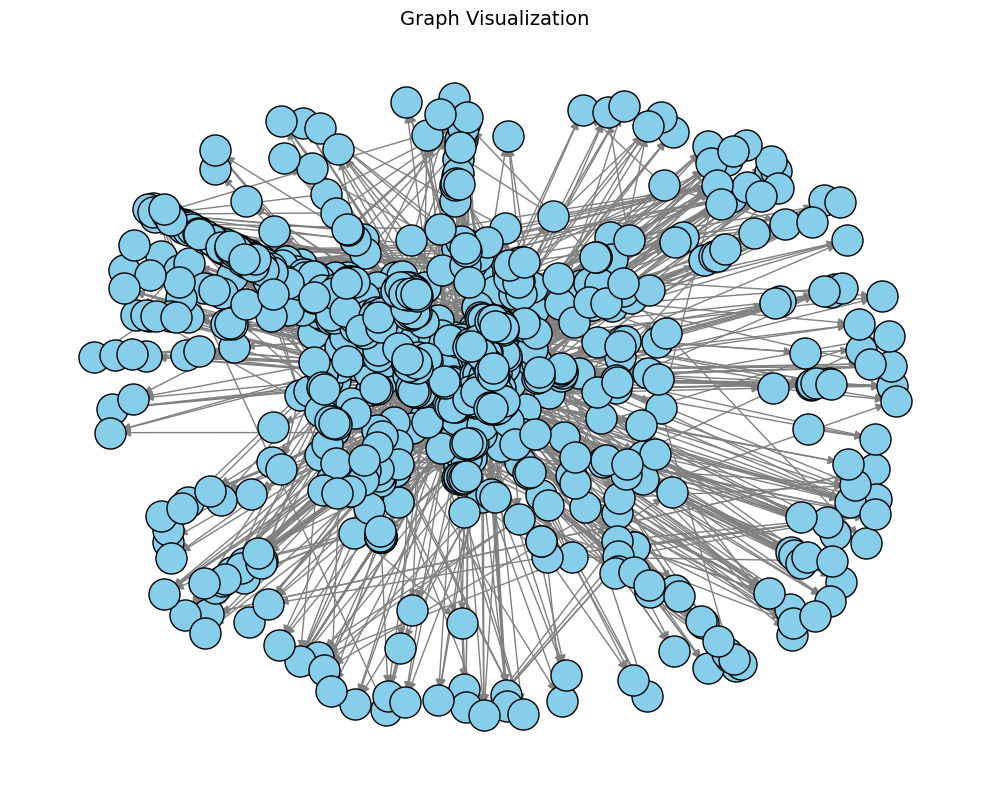

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue', edgecolors='black')

nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowstyle='-|>', arrowsize=12)


plt.title("Graph Visualization", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [35]:
nodes = list(G.nodes(data=True)) 

In [36]:
for i, (node_id, node_attrs) in enumerate(nodes, 1):
    print(node_id, node_attrs)

Sam {'type': 'Entity', 'label': 'Sam', 'name': 'Sam', 'sub_type': 'Person'}
Kelly {'type': 'Entity', 'label': 'Kelly', 'name': 'Kelly', 'sub_type': 'Person'}
Nadia Conti {'type': 'Entity', 'label': 'Nadia Conti', 'name': 'Nadia Conti', 'sub_type': 'Person'}
Elise {'type': 'Entity', 'label': 'Elise', 'name': 'Elise', 'sub_type': 'Person'}
Liam Thorne {'type': 'Entity', 'label': 'Liam Thorne', 'name': 'Liam Thorne', 'sub_type': 'Person'}
Samantha Blake {'type': 'Entity', 'label': 'Samantha Blake', 'name': 'Samantha Blake', 'sub_type': 'Person'}
Davis {'type': 'Entity', 'label': 'Davis', 'name': 'Davis', 'sub_type': 'Person'}
Rodriguez {'type': 'Entity', 'label': 'Rodriguez', 'name': 'Rodriguez', 'sub_type': 'Person'}
Sailor Shift {'type': 'Entity', 'label': 'Sailor Shift', 'name': 'Sailor Shift', 'sub_type': 'Person'}
Clepper Jensen {'type': 'Entity', 'label': 'Clepper Jensen', 'name': 'Clepper Jensen', 'sub_type': 'Person'}
Miranda Jordan {'type': 'Entity', 'label': 'Miranda Jordan', 'n